Compare my outputs with Julian's (doing very similar things but without the cutoff in MUV) for troubleshooting purposes

In [2]:
from escripts import edata
from escripts import eMCMC
from escripts import eplots

In [3]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt']
data_labels = ['Bouwens+21'] 
sorted_data = edata.get_sorted(file_names, data_labels)

# Initialize parameters
HST_params = eMCMC.build_param_data({})
JWST_params = eMCMC.build_param_data({'beta':{'fit': False, 'value': -1.36}, 'dbetadz': {'fit': False, 'value': 0.385}})

In [4]:
HST_UVLF = eMCMC.UVLF(sorted_data, HST_params)
JWST_UVLF = eMCMC.UVLF(sorted_data, JWST_params)

In [5]:
HST_file = '/Users/eb35267/Desktop/code/chains/just_HST/samples.h5'
all_data_file = '/Users/eb35267/Desktop/code/chains/all_data_all_params/samples.h5'

In [6]:
HST_samples, _, _, _  = HST_UVLF.get_fit(backend_file = HST_file)

ValueError: shape mismatch: value array of shape (2,12) could not be broadcast to indexing result of shape (0,)

In [ ]:
all_data_samples, _, _, _ = HST_UVLF.get_fit(backend_file = all_data_file)

In [ ]:
# Choose 1000 random points on the chain
HST_subsamples = HST_samples[np.random.randint(0, len(HST_samples), 1000)]
JWST_subsamples = all_data_samples[np.random.randint(0, len(all_data_samples), 1000)]

In [ ]:
# Calculate sigma(z, Mh) for each of them

def sigma(z, logM, params, zpivot = 8, Mhpivot = 11):
    sig0 = params[:, -4].reshape(-1, 1)
    dsigdz = params[:,-3].reshape(-1, 1)
    dsigdlogM = params[:,-2].reshape(-1, 1)
    min_sig = params[:,-1].reshape(-1, 1)

    sig = sig0 + dsigdz*(z-zpivot) + dsigdlogM*(logM - Mhpivot)

    return np.clip(sig0 + dsigdz*(z-zpivot) + dsigdlogM*(logM - Mhpivot), a_min = min_sig, a_max = None)

In [ ]:
logM = 10
zs = np.arange(4, 15, 1)

HST_sig = sigma(zs, logM, HST_subsamples)
JWST_sig = sigma(zs, logM, JWST_subsamples)

# Plot with np.percentile

In [ ]:
bounds_HST = np.percentile(HST_sig, q = [16, 50, 84], axis = 0)
bounds_JWST = np.percentile(JWST_sig, q = [16, 50, 84], axis = 0)

NameError: name 'HST_sig' is not defined

In [ ]:
HST_sig_12 = sigma(zs, 12, HST_subsamples)
JWST_sig_12 = sigma(zs, 12, JWST_subsamples)

In [ ]:
bounds_HST_12 = np.percentile(HST_sig_12, q = [34, 50, 68], axis = 0)
bounds_JWST_12 = np.percentile(JWST_sig_12, q = [34, 50, 68], axis = 0)

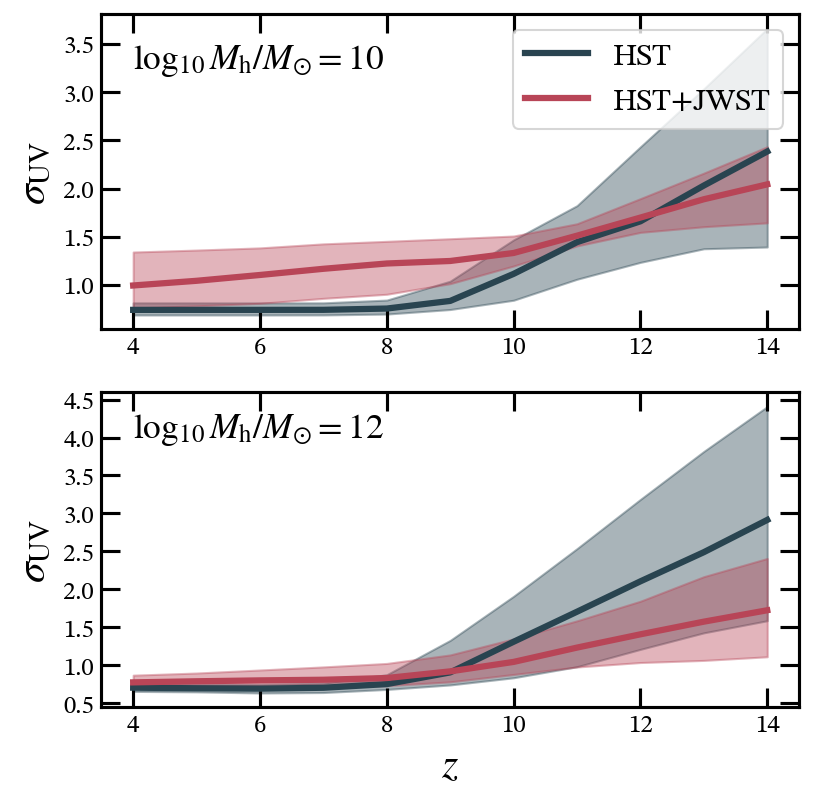

In [ ]:
fig, axs = plt.subplots(2, 1)
fig.set_size_inches(6, 6)
axs[0].fill_between(zs, bounds_HST[0], bounds_HST[2], color = eplots.navy, alpha = 0.4)
axs[0].plot(zs, bounds_HST[1], color = eplots.navy, label = 'HST')
axs[0].fill_between(zs, bounds_JWST[0], bounds_JWST[2], color = eplots.red, alpha = 0.4)
axs[0].plot(zs, bounds_JWST[1], color = eplots.red, ls = '-', label = 'HST+JWST')
axs[0].text(4, 3.25, r'$\log_{10}M_{\rm{h}}/M_{\odot} = 10$')

axs[1].fill_between(zs, bounds_HST_12[0], bounds_HST_12[2], color = eplots.navy, alpha = 0.4)
axs[1].plot(zs, bounds_HST_12[1], color = eplots.navy, label = 'HST')
axs[1].fill_between(zs, bounds_JWST_12[0], bounds_JWST_12[2], color = eplots.red, alpha = 0.4)
axs[1].plot(zs, bounds_JWST_12[1], color = eplots.red, ls = '-', label = 'HST+JWST')
axs[1].text(4, 4, r'$\log_{10}M_{\rm{h}}/M_{\odot} = 12$')


for ax in axs:
    ax.set_ylabel(r'$\sigma_{\rm{UV}}$')

axs[1].set_xlabel(r'$z$')
axs[0].legend(loc = 'upper right')
